In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:

# Load cleaned dataset
df = pd.read_csv(r"C:\Users\Sam\Desktop\Spotify_Genre_Segmentation\data\processed\spotify_cleaned.csv")

In [4]:

# Select features
features = ["danceability", "energy", "loudness", "speechiness",
            "acousticness", "instrumentalness", "liveness",
            "valence", "tempo"]

In [5]:

X = df[features]
y = df["playlist_genre"]

In [6]:

# Encode target labels (genre)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [7]:

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [8]:

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:

# Train Random Forest model
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_scaled, y_train)

# Predictions
y_pred = rf.predict(X_test_scaled)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.5379929952794275

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.64      0.64      1209
           1       0.50      0.43      0.46      1031
           2       0.35      0.32      0.33      1102
           3       0.46      0.46      0.46      1086
           4       0.57      0.64      0.61      1149
           5       0.66      0.74      0.70       990

    accuracy                           0.54      6567
   macro avg       0.53      0.54      0.53      6567
weighted avg       0.53      0.54      0.53      6567



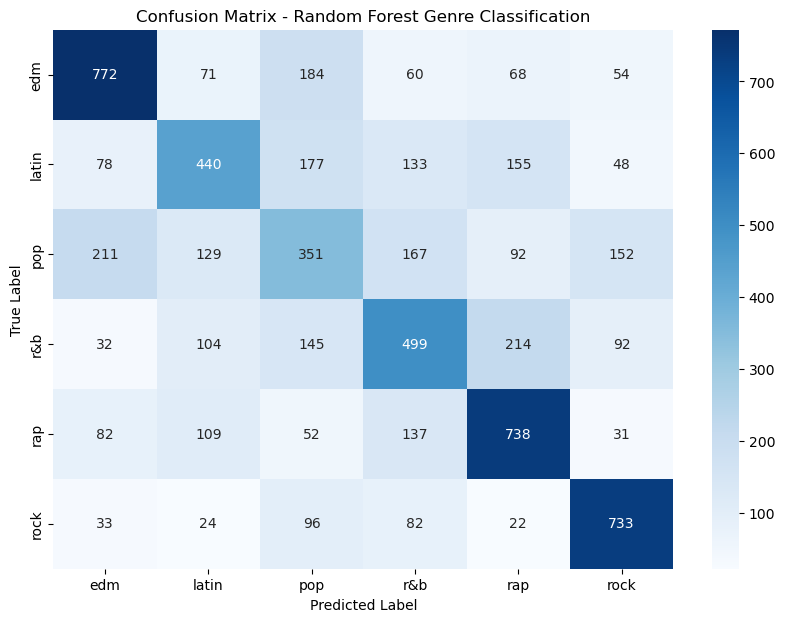

In [19]:

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest Genre Classification")
plt.show()

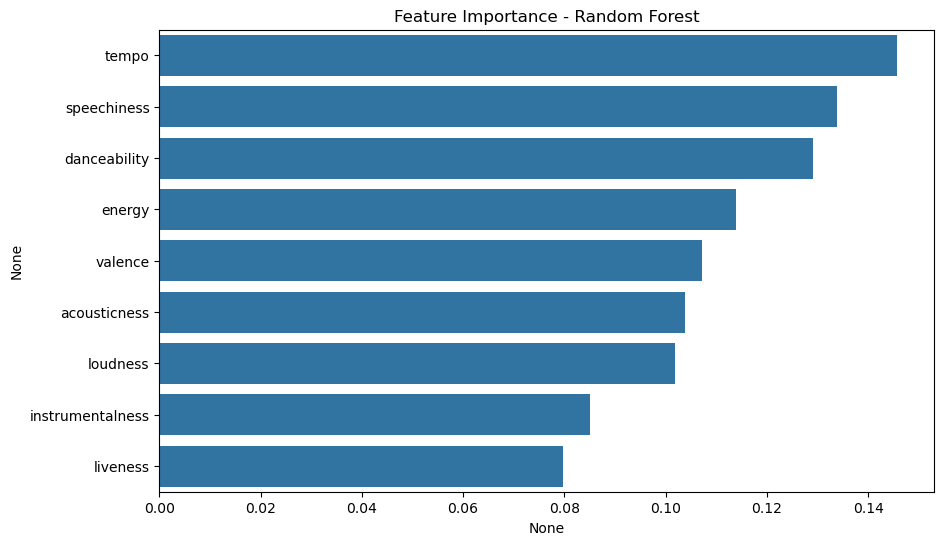

In [20]:
importances = rf.feature_importances_
feature_imp = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feature_imp, y=feature_imp.index)
plt.title("Feature Importance - Random Forest")
plt.show()

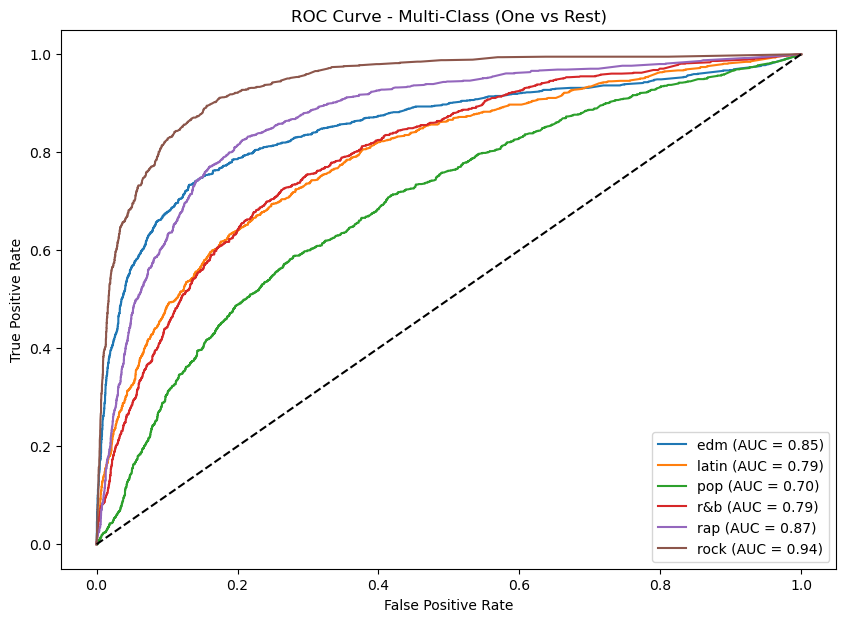

In [10]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Binarize the output (convert multiclass into one-vs-rest format)
y_test_bin = label_binarize(y_test, classes=[0,1,2,3,4,5])
y_pred_prob = rf.predict_proba(X_test_scaled)

# Plot ROC Curve for each class
plt.figure(figsize=(10,7))

for i in range(len(le.classes_)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{le.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Multi-Class (One vs Rest)")
plt.legend(loc="lower right")
plt.show()